# Lecture 2 - BasicML Tutorial Notebook 2: ML Regression with Vienna Airbnb Data

```{attention}
Students are encouraged to use the CSC Mahti platform. <br/>
<a href="https://www.mahti.csc.fi/pun/sys/dashboard/batch_connect/sys/ood-course-jupyter/session_contexts/new"><img alt="CSC badge" src="https://img.shields.io/badge/launch-CSC%20notebook-blue.svg" style="vertical-align:text-bottom"></a>
```

## Predicting nightly price from various features

In Notebook 1, we predicted whether a Vienna Airbnb listing was highly rated.  
Now we switch from **classification** to **regression**. This notebook mirrors the classification tutorial but for a **continuous target**: nightly Airbnb price.

The structure stays deliberately simple:

1. load and prepare the data  
2. inspect and clean the target  
3. build **one regression model step by step**  
4. compare that workflow across **multiple regressors**  
5. visualize model behaviour and residuals  
6. let students play with one or two hyperparameters  

This keeps the main regression ideas from class front and center:

- regression
- residual error
- train/test split
- preprocessing
- model comparison

## Notebook setup: install required libraries

If you are running this notebook in **Binder** or another temporary cloud environment, some Python libraries used in this course may not already be available.

Please **uncomment** and run the next code cell **once at the beginning of the notebook**.

Why do we do this?
- Binder sessions are temporary, so package availability can vary.
- Installing the required libraries at the start helps make sure everyone is working in the same software environment.
- This is especially important for geospatial libraries such as **GeoPandas**, which are needed to read and work with spatial data.

How to use it:
1. Run the next code cell.
2. Wait until the installation finishes.
3. If Binder asks you to restart the kernel, do that.
4. Then continue running the notebook from top to bottom.

Required external libraries in this course:
- numpy
- pandas
- matplotlib
- seaborn
- scikit-learn
- geopandas
- pyogrio

In [44]:
## Run this cell once at the start of the notebook when using Binder

#!pip install -q numpy pandas matplotlib seaborn scikit-learn geopandas pyogrio
#print("Setup complete. If you see any import errors later, restart the kernel and run the notebook again from the top.")

In [45]:
# ============================================================
# 0. Imports and notebook settings
# ============================================================
from pathlib import Path
import ast
import re
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.frameon"] = True
sns.set_theme(style="whitegrid", context="notebook")

pd.set_option("display.max_columns", 120)
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor


## Semi-goal 1 — Load the data and make it spatial

We again begin with a geospatial table, because price is not only a property characteristic.
It is also a **location question**.

In [46]:
# ============================================================
# 1. Resolve the file paths
# ============================================================
DATA_DIRS = [
    Path("."),
    Path("./data"),
]

def find_file(filename):
    for folder in DATA_DIRS:
        path = folder / filename
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {filename} in any of: {DATA_DIRS}")

csv_path = find_file("listings_Vienna.csv")
geojson_path = find_file("neighbourhoods.geojson")

print("CSV path:", csv_path)
print("GeoJSON path:", geojson_path)

CSV path: data\listings_Vienna.csv
GeoJSON path: data\neighbourhoods.geojson


In [47]:
# ============================================================
# 2. Load the raw Airbnb table and the neighbourhood polygons
# ============================================================
df = pd.read_csv(csv_path)
neighbourhoods = gpd.read_file(geojson_path)

# Turn the Airbnb table into a GeoDataFrame so that each listing becomes a point.
airbnb_gdf = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326",
)

# Spatial join: assign each point listing to the polygon that contains it.
spatial = gpd.sjoin(
    airbnb_gdf,
    neighbourhoods[["neighbourhood", "geometry"]],
    how="left",
    predicate="within",
)

# The spatial join creates both left and right neighbourhood columns.
spatial = spatial.rename(columns={"neighbourhood_right": "neighbourhood_joined"})

# If a point does not match a polygon, fall back to the original cleaned neighbourhood column.
spatial["neighbourhood_joined"] = spatial["neighbourhood_joined"].fillna(
    spatial["neighbourhood_cleansed"]
)

print("Original table shape:", df.shape)
print("Spatial table shape: ", spatial.shape)
display(spatial[[
    "latitude", "longitude", "neighbourhood_cleansed", "neighbourhood_joined"
]].head())

Original table shape: (14123, 79)
Spatial table shape:  (14123, 82)


,latitude,longitude,neighbourhood_cleansed,neighbourhood_joined
0,48.18434,16.32701,Rudolfsheim-Fnfhaus,Rudolfsheim-Fnfhaus
1,48.21778,16.37847,Leopoldstadt,Leopoldstadt
2,48.18467,16.32795,Rudolfsheim-Fnfhaus,Rudolfsheim-Fnfhaus
3,48.18445,16.32722,Rudolfsheim-Fnfhaus,Rudolfsheim-Fnfhaus
4,48.21543,16.30939,Ottakring,Ottakring


In [48]:
# ============================================================
# 3. Feature engineering, we discussed in detail in the classification tutorial
# ============================================================
def parse_percent(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().replace("%", "")
    if text == "":
        return np.nan
    try:
        return float(text) / 100.0
    except ValueError:
        return np.nan

def parse_tf(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    if text in {"t", "true", "yes", "1"}:
        return 1
    if text in {"f", "false", "no", "0"}:
        return 0
    return np.nan

def parse_bathrooms(text):
    if pd.isna(text):
        return np.nan
    s = str(text).lower()
    if "half-bath" in s:
        return 0.5
    match = re.search(r"(\d+(?:\.\d+)?)", s)
    if match:
        return float(match.group(1))
    if "bath" in s:
        return 1.0
    return np.nan

def count_amenities(text):
    if pd.isna(text):
        return np.nan
    s = str(text).strip()
    if s in {"", "[]"}:
        return 0
    try:
        items = ast.literal_eval(s)
        if isinstance(items, (list, tuple, set)):
            return len(items)
    except Exception:
        pass
    s = s.strip("[]")
    if not s:
        return 0
    parts = [part for part in s.split('","') if part.strip()]
    return len(parts)

def parse_price(value):
    if pd.isna(value):
        return np.nan
    text = str(value).replace("$", "").replace(",", "").strip()
    if text == "":
        return np.nan
    try:
        return float(text)
    except ValueError:
        return np.nan

prep_df = spatial.copy()

prep_df["host_response_rate_num"] = prep_df["host_response_rate"].map(parse_percent)
prep_df["host_acceptance_rate_num"] = prep_df["host_acceptance_rate"].map(parse_percent)
prep_df["host_is_superhost_num"] = prep_df["host_is_superhost"].map(parse_tf)
prep_df["host_identity_verified_num"] = prep_df["host_identity_verified"].map(parse_tf)
prep_df["instant_bookable_num"] = prep_df["instant_bookable"].map(parse_tf)
prep_df["bathrooms_num"] = prep_df["bathrooms_text"].map(parse_bathrooms)
prep_df["amenity_count"] = prep_df["amenities"].map(count_amenities)

prep_df["host_since"] = pd.to_datetime(prep_df["host_since"], errors="coerce")
prep_df["last_review"] = pd.to_datetime(prep_df["last_review"], errors="coerce")
prep_df["last_scraped"] = pd.to_datetime(prep_df["last_scraped"], errors="coerce")

reference_date = prep_df["last_scraped"].max()

prep_df["host_tenure_days"] = (reference_date - prep_df["host_since"]).dt.days
prep_df["days_since_last_review"] = (reference_date - prep_df["last_review"]).dt.days
prep_df["review_scores_rating"] = pd.to_numeric(prep_df["review_scores_rating"], errors="coerce")
prep_df["price_num"] = prep_df["price"].map(parse_price)

engineered_cols = [
    "bathrooms_num",
    "amenity_count",
    "host_identity_verified_num",
    "host_response_rate_num",
    "host_acceptance_rate_num",
    "host_tenure_days",
    "days_since_last_review",
    "price_num",
]
display(prep_df[engineered_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
bathrooms_num,14117.0,1.182298,0.471834,0.0,1.00,1.00,1.0,12.0
amenity_count,14123.0,28.504355,14.268076,0.0,17.00,29.00,39.0,83.0
host_identity_verified_num,14120.0,0.897167,0.303751,0.0,1.00,1.00,1.0,1.0
host_response_rate_num,10413.0,0.935600,0.174523,0.0,0.97,1.00,1.0,1.0
host_acceptance_rate_num,10942.0,0.893048,0.226279,0.0,0.93,0.99,1.0,1.0
host_tenure_days,14120.0,2570.738527,1451.524949,4.0,1168.00,2794.50,3751.0,6103.0
days_since_last_review,11834.0,497.968650,897.402461,1.0,17.00,56.00,400.0,4273.0
price_num,10306.0,156.727634,533.463760,13.0,66.00,93.00,140.0,10000.0


### Visualizing the target variable: the outlier problem

Before we build a model to predict the nightly price (`price_num`), we need to understand the shape of our data. 

In real estate and rental data, prices are almost never distributed evenly (like a bell curve). Instead, they are usually **highly right-skewed**. This means the vast majority of listings are affordable, but a tiny handful of luxury villas or penthouses are listed at astronomical prices (in our case, up to $10,000 a night!).

Let's visualize this skewness using a **Histogram** (to see the spread) and a **Boxplot** (to explicitly spot the outliers). 

**Why does this matter for Machine Learning?** Regression models (like Linear Regression) try to draw a line that minimizes the average error. If we leave these extreme $10,000/night outliers in our dataset, the model will get "distracted" trying to accommodate them, and it will become much worse at predicting the price of a normal, everyday apartment. For this tutorial, we will identify these extreme outliers and remove them.

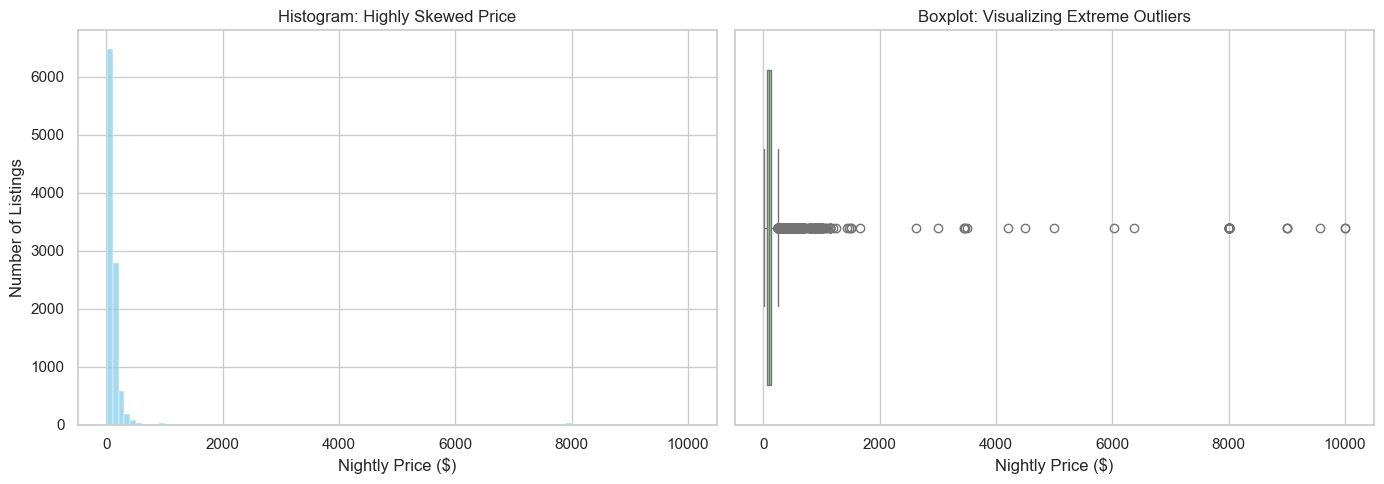

Mathematical Skewness of price_num: 14.17
Anything > 1 is considered highly skewed!


In [49]:
# ============================================================
# Inspecting the distribution and outliers of our target (Price)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogram
sns.histplot(prep_df["price_num"], bins=100, ax=axes[0], color="skyblue")
axes[0].set_title("Histogram: Highly Skewed Price")
axes[0].set_xlabel("Nightly Price ($)")
axes[0].set_ylabel("Number of Listings")

# 2. Boxplot
sns.boxplot(x=prep_df["price_num"], ax=axes[1], color="lightgreen")
axes[1].set_title("Boxplot: Visualizing Extreme Outliers")
axes[1].set_xlabel("Nightly Price ($)")

plt.tight_layout()
plt.show()

# Calculate and print the skewness (A perfectly normal distribution has a skew of 0)
price_skew = prep_df['price_num'].skew()
print(f"Mathematical Skewness of price_num: {price_skew:.2f}")
print("Anything > 1 is considered highly skewed!")

## Sub-goal 2 — Clean the regression target (nightly price)

As we just saw in our visualizations, the `price_num` variable is highly skewed. If we leave $10,000/night penthouses in our dataset, our model will perform poorly when trying to predict the price of a standard, everyday apartment.

To fix this, we will clean our target variable in three logical steps:

1. **Remove missing prices:** A model cannot learn to predict a price that is blank!
2. **Remove non-positive prices:** An Airbnb cannot cost $0 or a negative amount.
3. **Remove extreme outliers using the IQR Rule:** We calculate the "Interquartile Range" (IQR), which represents the middle 50% of our normal data. Using this, we calculate a mathematical `upper_fence`. Any listing priced higher than this fence is considered an extreme outlier and is dropped from our training data.

This keeps our dataset robust and ensures a few extreme luxury listings don't break our model.

In [50]:
# ============================================================
# 4. Clean the target variable
# ============================================================
reg_df = prep_df.loc[prep_df["price_num"].notna()].copy()
reg_df = reg_df.loc[reg_df["price_num"] > 0].copy()

q1 = reg_df["price_num"].quantile(0.25)
q3 = reg_df["price_num"].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

before_rows = len(reg_df)
reg_df = reg_df.loc[reg_df["price_num"] <= upper_fence].copy()
after_rows = len(reg_df)

print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Upper fence: {upper_fence:.2f}")
print(f"Rows before filtering: {before_rows}")
print(f"Rows after filtering:  {after_rows}")
print(f"Rows removed:          {before_rows - after_rows}")

Q1: 66.00
Q3: 140.00
IQR: 74.00
Upper fence: 251.00
Rows before filtering: 10306
Rows after filtering:  9595
Rows removed:          711


## Quick map check

This time we color a sample of listings by nightly price.

That gives us a first visual hint that price may vary spatially across the city.

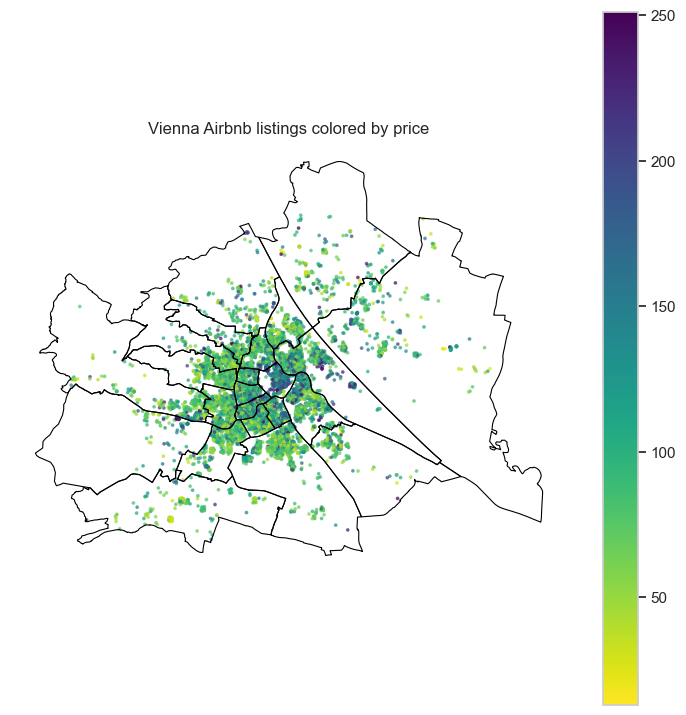

In [51]:
# ============================================================
# 5. Quick spatial look at the price variable
# ============================================================


fig, ax = plt.subplots(figsize=(9, 9))
neighbourhoods.boundary.plot(ax=ax, linewidth=0.8, color="black")
reg_df.sample(len(reg_df), random_state=RANDOM_STATE).plot(
    ax=ax,
    column="price_num",
    cmap="viridis_r",
    legend=True,
    markersize=3,
    alpha=0.6,
)
ax.set_title("Vienna Airbnb listings colored by price")
ax.set_axis_off()
plt.show()

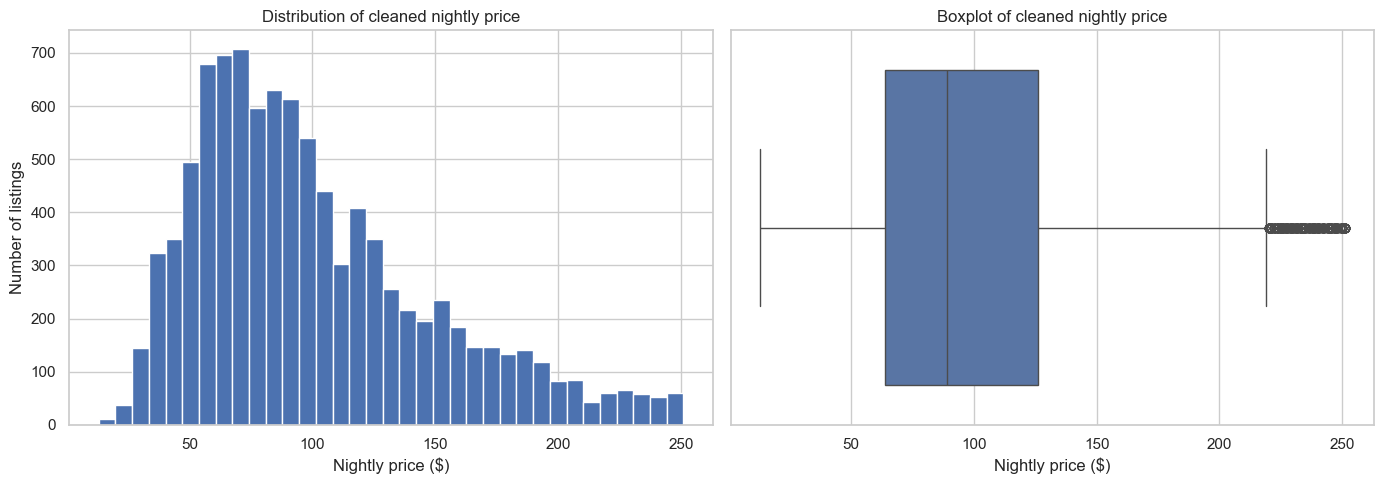

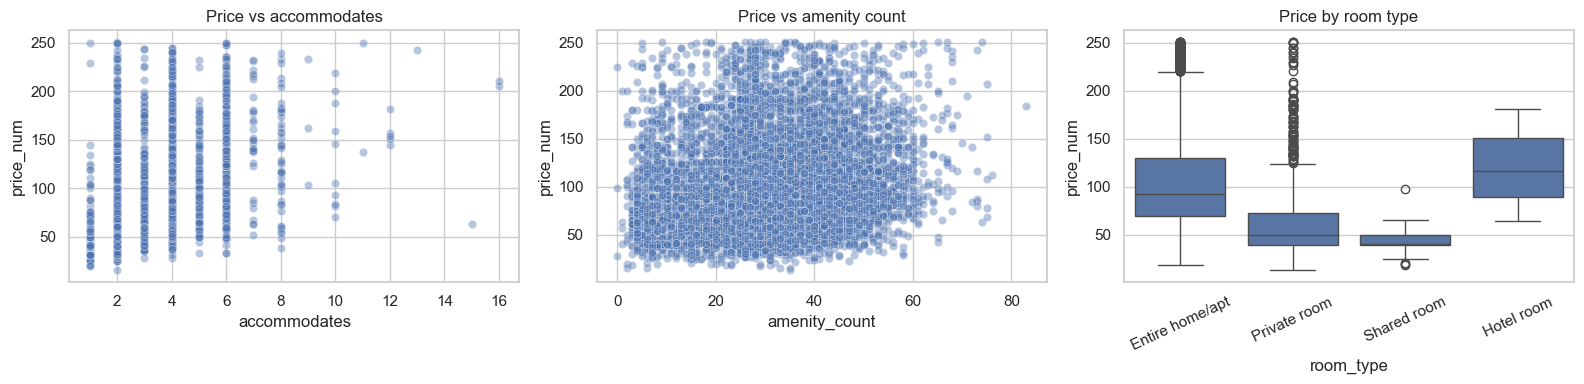

In [52]:
# ============================================================
# 6. Visualize the cleaned target and a few relationships
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(reg_df["price_num"], bins=35)
axes[0].set_title("Distribution of cleaned nightly price")
axes[0].set_xlabel("Nightly price ($)")
axes[0].set_ylabel("Number of listings")

sns.boxplot(x=reg_df["price_num"], ax=axes[1])
axes[1].set_title("Boxplot of cleaned nightly price")
axes[1].set_xlabel("Nightly price ($)")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.scatterplot(
    data=reg_df.sample(min(2500, len(reg_df)), random_state=RANDOM_STATE),
    x="accommodates",
    y="price_num",
    alpha=0.4,
    ax=axes[0],
)
axes[0].set_title("Price vs accommodates")

sns.scatterplot(
    data=reg_df.sample( len(reg_df), random_state=RANDOM_STATE),
    x="amenity_count",
    y="price_num",
    alpha=0.4,
    ax=axes[1],
)
axes[1].set_title("Price vs amenity count")

sns.boxplot(data=reg_df, x="room_type", y="price_num", ax=axes[2])
axes[2].set_title("Price by room type")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

## Semi-goal 3 — Choose features intentionally for price prediction

We keep the current regression feature selection because it gave a stable standalone notebook.

Again, we separate:

- numeric features
- categorical features

In [53]:
# ============================================================
# 7. Feature lists for the regression task
# ============================================================
numeric_features = [
    "latitude",
    "longitude",
    "accommodates",
    "bathrooms_num",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "host_response_rate_num",
    "host_acceptance_rate_num",
    "host_is_superhost_num",
    "host_identity_verified_num",
    "instant_bookable_num",
    "host_tenure_days",
    "days_since_last_review",
    "amenity_count",
    "calculated_host_listings_count",
    "review_scores_rating",
]

categorical_features = [
    "room_type",
    "property_type",
    "neighbourhood_joined",
    "host_response_time",
]

X = reg_df[numeric_features + categorical_features].copy()
y = reg_df["price_num"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

print("Training shape:", X_train.shape)
print("Testing shape: ", X_test.shape)
print("\nNumeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Training shape: (7196, 25)
Testing shape:  (2399, 25)

Numeric features: 21
Categorical features: 4


## Semi-goal 4 — Build one regression model step by step

We start with **Linear Regression**.

Recall that:

> The prediction ($\hat{y}$) is a weighted combination of the input features

So just as in the classification notebook, we first build the workflow piece by piece.

In [54]:
# ============================================================
# 8. Numeric preprocessing branch
# ============================================================
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

numeric_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [55]:
# ============================================================
# 9. Categorical preprocessing branch
# ============================================================
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

categorical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [56]:
# ============================================================
# 10. Combine both branches into one preprocessor
# ============================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['latitude', 'longitude', 'accommodates',
                                  'bathrooms_num', 'bedrooms', 'beds',
                                  'minimum_nights', 'maximum_nights',
                                  'availability_365', 'number_of_reviews',
                                  'reviews_per_month', 'host_response_rate_num',
                                  'host_acceptance_rate_num',
                                  'h...
                                  'host_identity_verified_num',
                                  'instant_bookable_num', 'host_tenure_days',
                                  'days_since_last_review', 'amenity_count',
                                  'calculated_host_listings_count',
                                  'review_scores_rating']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['room_type', 'property_type',
                                  'neighbourhood_joined',
                                  'host_response_time'])])

In [57]:
# ============================================================
# 11. Build the first full pipeline: Linear Regression
# ============================================================
from sklearn.linear_model import LinearRegression

linear_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

linear_pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'accommodates',
                                                   'bathrooms_num', 'bedrooms',
                                                   'beds', 'minimum_nights',
                                                   'maximum_nights',
                                                   'availability_365',
                                                   'number_of_reviews',
                                                   'reviews_per_month',
                                                   'host_response_rate_nu...
                                                   'host_tenure_days',
                                                   'days_since_last_review',
                                                   'amenity_count',
                                                   'calculated_host_listings_count',
                                                   'review_scores_rating']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['room_type', 'property_type',
                                                   'neighbourhood_joined',
                                                   'host_response_time'])])),
                ('regressor', LinearRegression())])

In [58]:
# ============================================================
# 12. Fit the first regression model and evaluate it
# ============================================================
from sklearn.metrics import mean_squared_error, r2_score

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

linear_pipe.fit(X_train, y_train)
linear_pred = linear_pipe.predict(X_test)

linear_results = pd.DataFrame(
    [{
        "Model": "Linear Regression",
        "RMSE": rmse(y_test, linear_pred),
        "R2": r2_score(y_test, linear_pred),
    }]
)

display(linear_results)

,Model,RMSE,R2
0,Linear Regression,37.23557,0.408173


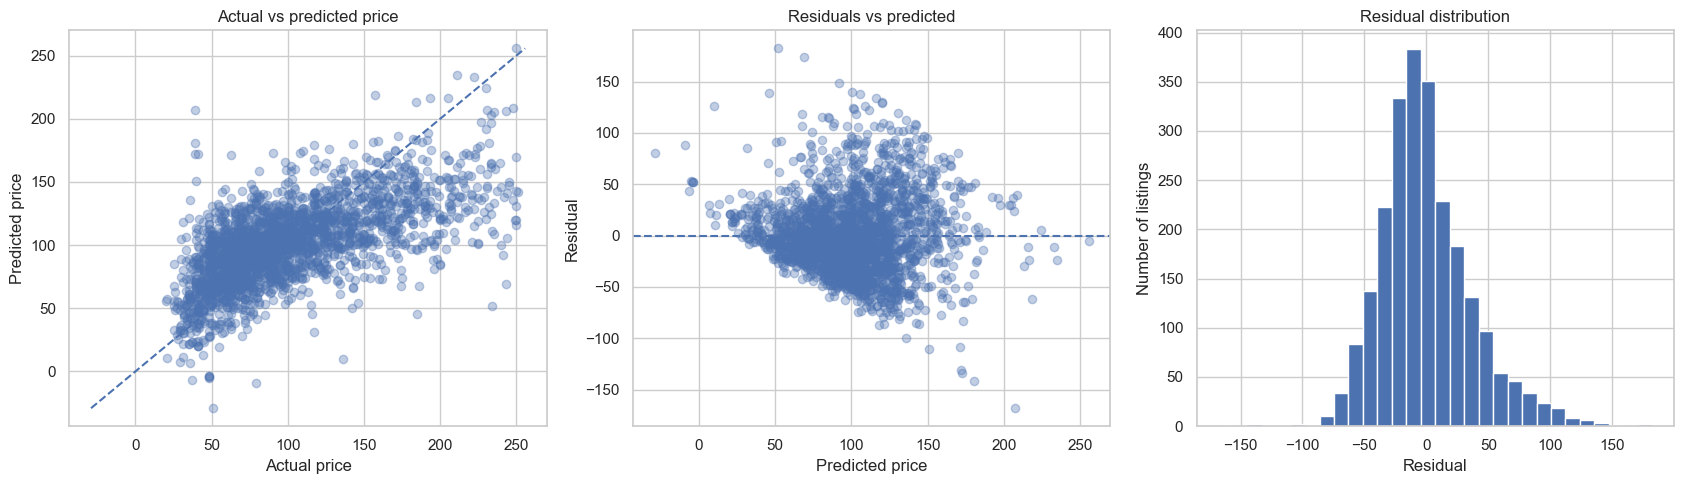

In [59]:
# ============================================================
# 13. Visualize the first model: prediction and residuals
# ============================================================
residuals = y_test - linear_pred

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].scatter(y_test, linear_pred, alpha=0.35)
min_val = min(y_test.min(), linear_pred.min())
max_val = max(y_test.max(), linear_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], linestyle="--")
axes[0].set_title("Actual vs predicted price")
axes[0].set_xlabel("Actual price")
axes[0].set_ylabel("Predicted price")

axes[1].scatter(linear_pred, residuals, alpha=0.35)
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Residuals vs predicted")
axes[1].set_xlabel("Predicted price")
axes[1].set_ylabel("Residual")

axes[2].hist(residuals, bins=30)
axes[2].set_title("Residual distribution")
axes[2].set_xlabel("Residual")
axes[2].set_ylabel("Number of listings")

plt.tight_layout()
plt.show()

## Semi-goal 5 — A reusable helper for regression models

Just as in classification, the helper below does not introduce a new ML concept.
It simply packages the repeated pattern:

- build pipeline
- fit model
- predict
- evaluate
- save results

In [60]:
# ============================================================
# 14. Helper function for processed regressors
# ============================================================
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_pipeline_regressors(models, preprocessor, X_train, X_test, y_train, y_test):
    # A list to collect one summary dictionary per model.
    rows = []

    # A dictionary to store the fitted pipelines, keyed by model name.
    fitted_pipelines = {}

    # A dictionary to store the predictions of each fitted pipeline.
    predictions = {}

    # Loop through each candidate regressor.
    for model_name, model in models.items():

        # Build a complete pipeline: preprocess first, then apply the regressor.
        pipe = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("regressor", model),
            ]
        )

        # Fit the full workflow on the training set.
        pipe.fit(X_train, y_train)

        # Predict the prices of unseen test examples.
        y_pred = pipe.predict(X_test)

        # Compute the evaluation metrics and save them as one row.
        rows.append(
            {
                "Model": model_name,
                "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
                "R2": r2_score(y_test, y_pred),
            }
        )

        # Store the trained pipeline so we can inspect it later.
        fitted_pipelines[model_name] = pipe

        # Store the model predictions for later plots.
        predictions[model_name] = y_pred

    # Convert the collected rows into a clean comparison table.
    results = (
        pd.DataFrame(rows)
        .sort_values("RMSE", ascending=True)
        .reset_index(drop=True)
    )

    # Return all useful objects.
    return results, fitted_pipelines, predictions

## Semi-goal 6 — Compare multiple regression models

We now keep the same data preparation pipeline and compare three regressors:

- Linear Regression
- Lasso Regression
- Decision Tree Regressor

This exactly supports the assignment logic you described:

students first see the pattern here, and later implement the missing models themselves.

In [61]:
# ============================================================
# 15. Compare multiple regression models
# ============================================================
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor

regression_models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(alpha=0.001, max_iter=10000),
    "Decision Tree Regressor": DecisionTreeRegressor(
        random_state=RANDOM_STATE,
        max_depth=10,
        min_samples_leaf=8,
    ),
}

regression_results, regression_pipes, regression_preds = evaluate_pipeline_regressors(
    regression_models,
    preprocessor,
    X_train,
    X_test,
    y_train,
    y_test,
)

display(regression_results)

,Model,RMSE,R2
0,Linear Regression,37.235570,0.408173
1,Lasso Regression,37.242044,0.407968
2,Decision Tree Regressor,38.022182,0.382904


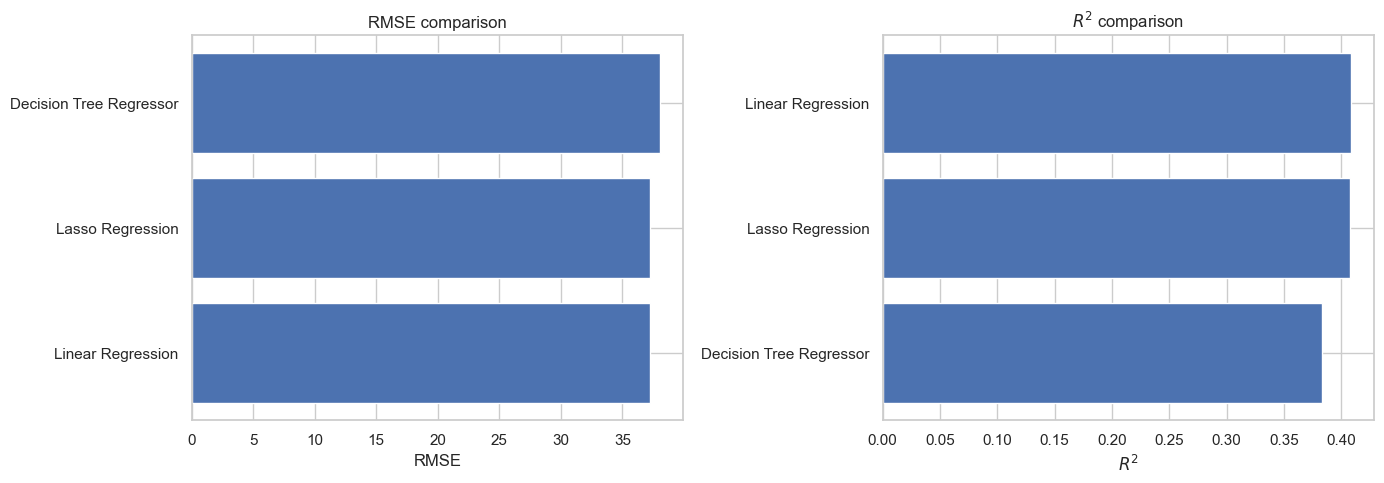

In [62]:
# ============================================================
# 16. Visual comparison of the three regressors
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ordered_rmse = regression_results.sort_values("RMSE", ascending=True)
axes[0].barh(ordered_rmse["Model"], ordered_rmse["RMSE"])
axes[0].set_title("RMSE comparison")
axes[0].set_xlabel("RMSE")
axes[0].set_ylabel("")

ordered_r2 = regression_results.sort_values("R2", ascending=True)
axes[1].barh(ordered_r2["Model"], ordered_r2["R2"])
axes[1].set_title("$R^2$ comparison")
axes[1].set_xlabel("$R^2$")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

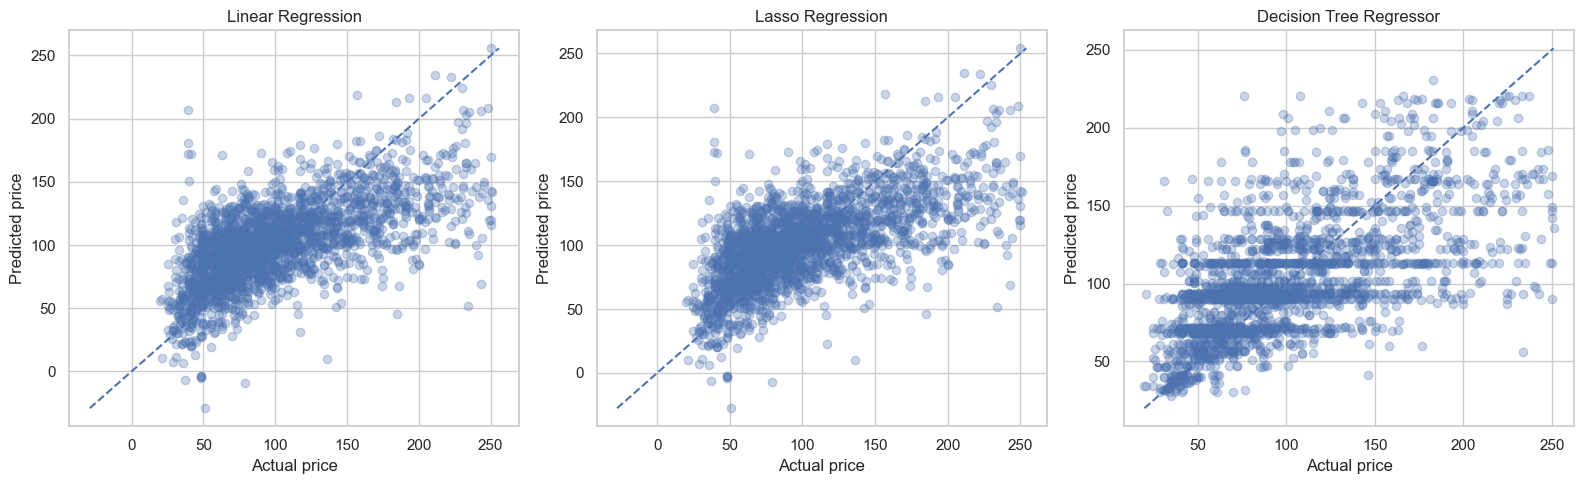

In [63]:
# ============================================================
# 17. Actual vs predicted plots for all three regressors
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, model_name in zip(axes, regression_results["Model"]):
    preds = regression_preds[model_name]
    ax.scatter(y_test, preds, alpha=0.3)

    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    ax.set_title(model_name)
    ax.set_xlabel("Actual price")
    ax.set_ylabel("Predicted price")

plt.tight_layout()
plt.show()

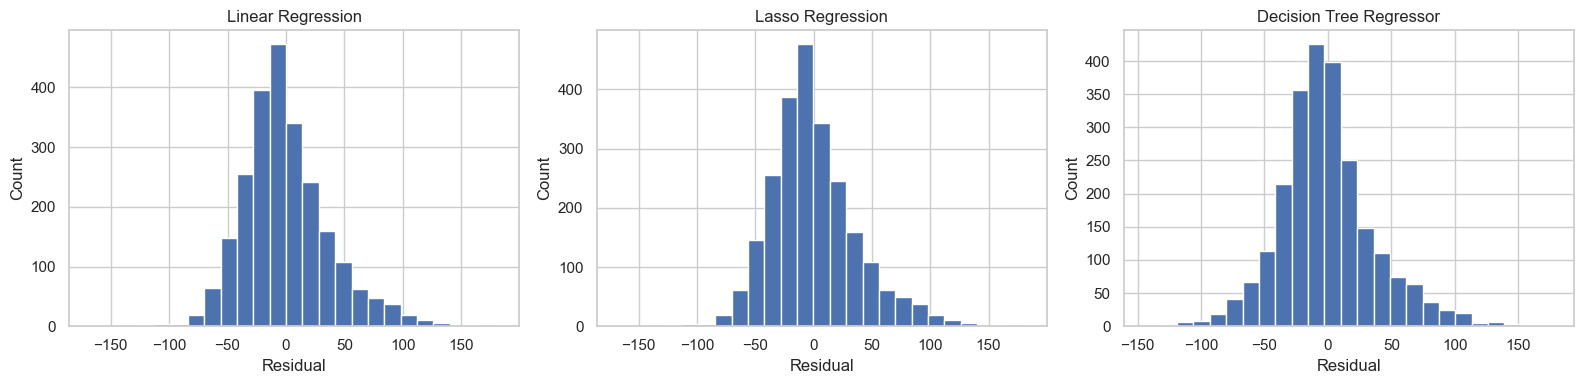

In [64]:
# ============================================================
# 18. Residual comparison across models
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, model_name in zip(axes, regression_results["Model"]):
    residuals = y_test - regression_preds[model_name]
    ax.hist(residuals, bins=25)
    ax.set_title(model_name)
    ax.set_xlabel("Residual")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

,feature,importance
4,num__bedrooms,0.219178
19,num__calculated_host_listings_count,0.100566
52,cat__property_type_Private room in rental unit,0.090233
74,cat__neighbourhood_joined_Innere Stadt,0.078701
3,num__bathrooms_num,0.069826
1,num__longitude,0.057603
10,num__reviews_per_month,0.054156
0,num__latitude,0.051502
2,num__accommodates,0.050254
6,num__minimum_nights,0.039294


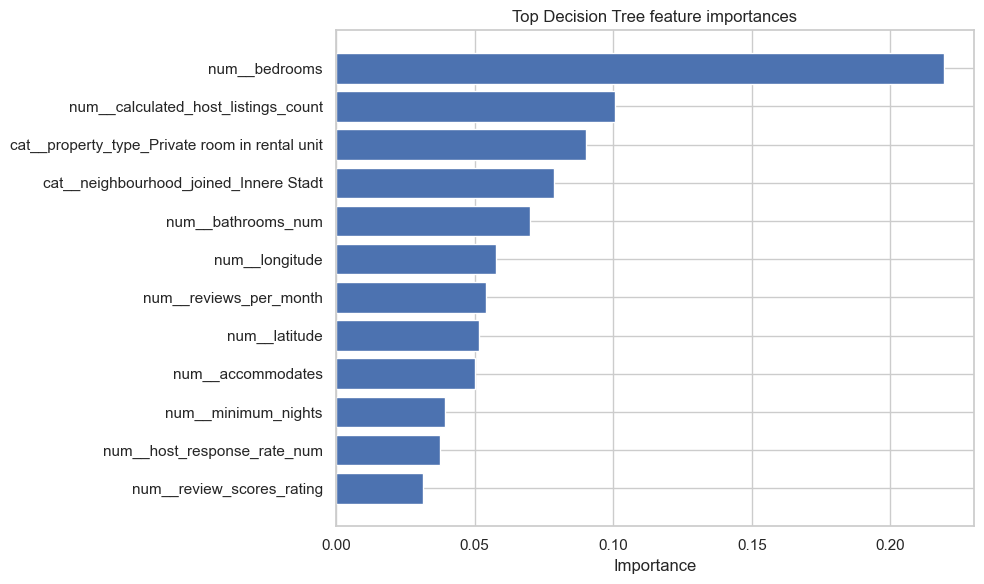

In [65]:
# ============================================================
# 19. What did the Decision Tree focus on?
# ============================================================
tree_pipe = regression_pipes["Decision Tree Regressor"]
fitted_preprocessor = tree_pipe.named_steps["preprocessor"]
fitted_tree = tree_pipe.named_steps["regressor"]

feature_names = fitted_preprocessor.get_feature_names_out()
importances = fitted_tree.feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

display(importance_df.head(15))

plt.figure(figsize=(10, 6))
top_features = importance_df.head(12).sort_values("importance", ascending=True)
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top Decision Tree feature importances")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Semi-goal 7 — Hyperparameter playground

We keep the tuning idea gentle and visual.

## Hyperparameter playground for **Lasso** regression

Here we explore the regularization strength of regularization

In plain language:

- smaller `alpha` means less penalty
- larger `alpha` means more penalty
- we watch what happens to test RMSE

,alpha,RMSE,R2
0,0.001,37.242044,0.407968
1,0.005,37.243841,0.407910
2,0.010,37.264347,0.407258
3,0.050,37.455634,0.401157
4,0.100,37.647411,0.395009
5,0.500,39.224537,0.343259
6,1.000,40.384673,0.303836


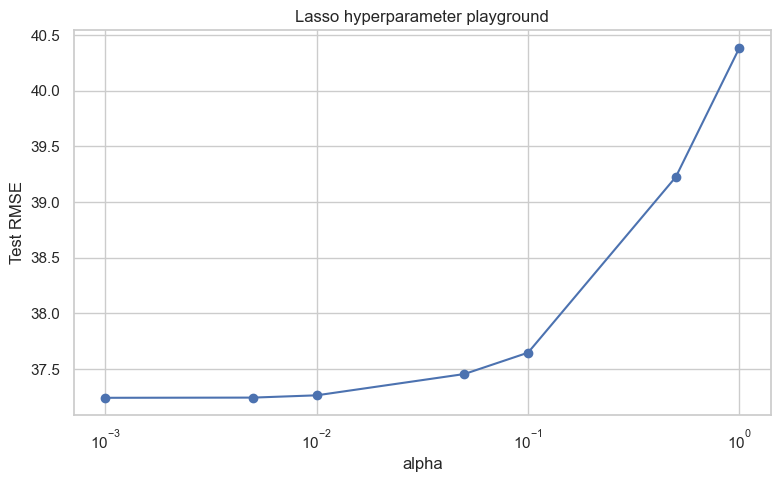

In [66]:
# ============================================================
# 20. Hyperparameter playground for Lasso
# ============================================================
alpha_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
lasso_rows = []

for alpha in alpha_values:
    lasso_pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", Lasso(alpha=alpha, max_iter=20000)),
        ]
    )
    lasso_pipe.fit(X_train, y_train)
    lasso_pred = lasso_pipe.predict(X_test)

    lasso_rows.append(
        {
            "alpha": alpha,
            "RMSE": np.sqrt(mean_squared_error(y_test, lasso_pred)),
            "R2": r2_score(y_test, lasso_pred),
        }
    )

lasso_tuning = pd.DataFrame(lasso_rows)
display(lasso_tuning)

plt.figure(figsize=(9, 5))
plt.plot(lasso_tuning["alpha"], lasso_tuning["RMSE"], marker="o")
plt.xscale("log")
plt.title("Lasso hyperparameter playground")
plt.xlabel("alpha")
plt.ylabel("Test RMSE")
plt.show()

## Sub-goal 8 — Hyperparameter playground for Decision Trees

Recall that a Decision Tree has a setting called `max_depth`. 

The `max_depth` hyperparameter controls how many layers of "If/Else" questions the tree is allowed to ask before making a final price prediction. 
* If `max_depth` is too low, the tree is too simple and predicts roughly the same average price for everyone (**Underfitting**).
* If `max_depth` is too high, the tree essentially memorizes the exact prices of the training data, but fails to generalize to new, unseen Airbnb listings (**Overfitting**).

Let's test depths from 1 to 15 and see how it affects our Test RMSE (remember, lower error is better!).

,max_depth,Test RMSE
0,1,45.168888
1,2,43.327712
2,3,41.636947
3,4,40.662776
4,5,39.793370
5,6,39.214813
6,7,38.486852
7,8,38.136314
8,9,38.127737
9,10,38.311921


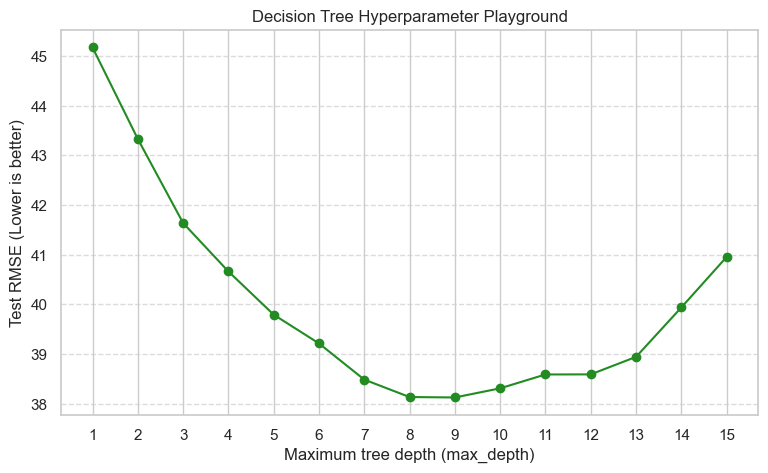

In [67]:
# ============================================================
# 19. Hyperparameter playground for Decision Tree (Regression)
# ============================================================
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Let's test tree depths from 1 (very simple) to 15 (very complex)
depth_values = list(range(1, 16))
dt_rows = []

for depth in depth_values:
    dt_pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            # random_state=42 ensures everyone gets the exact same results
            ("regressor", DecisionTreeRegressor(max_depth=depth, random_state=42)),
        ]
    )
    
    # Train and predict
    dt_pipe.fit(X_train, y_train)
    dt_pred = dt_pipe.predict(X_test)
    
    # Calculate RMSE (Root Mean Squared Error)
    rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
    
    # Save the results
    dt_rows.append(
        {
            "max_depth": depth,
            "Test RMSE": rmse,
        }
    )

# Create a clean table
dt_tuning = pd.DataFrame(dt_rows)
display(dt_tuning.head(10)) # Show the first 10 rows

# Plot the results
plt.figure(figsize=(9, 5))
plt.plot(dt_tuning["max_depth"], dt_tuning["Test RMSE"], marker="o", color="forestgreen")
plt.title("Decision Tree Hyperparameter Playground")
plt.xlabel("Maximum tree depth (max_depth)")
plt.ylabel("Test RMSE (Lower is better)")
plt.xticks(depth_values)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 🎉 Final summary: What you have achieved

Great job! You have successfully built a complete Machine Learning workflow for **Regression**. You moved from predicting categories to predicting actual, continuous numbers (nightly prices). 

Here is a look at the powerful skills you just added to your Data Science toolkit:

* **Tamed messy real-world targets:** You learned that real data isn't perfect. You visualized highly skewed prices and successfully used the IQR rule to remove extreme outliers.
* **Built a regression assembly line:** You proved that the exact same pipeline logic (`ColumnTransformer`) used for classification works beautifully for regression models too.
* **Measured the mistakes:** Instead of simple "Accuracy," you learned to evaluate models using **RMSE** (how far off the price is on average) and **$R^2$** (how well the model explains the data).
* **Looked under the hood:** You used **Residual Plots** to actually *see* where your models were making mistakes, rather than just staring at a table of numbers.
* **Navigated the bias-variance tradeoff:** By tweaking the Decision Tree's maximum depth, you witnessed firsthand how a model can easily tip from being too simple (underfitting) to memorizing the data perfectly but failing in the real world (overfitting).

**What is next?**
You now hold the complete blueprints for both Classification and Regression. In your graded assignment, you will step into the driver's seat. You will use these exact workflows to clean the data and implement advanced models—like Ridge Regression and Random Forests—completely on your own. 

You are ready. Let's go build some models!